# Week 4: Introduction to Machine Learning

Welcome! In this chapter we build the *foundations* that every machine learning model rests on.
Later chapters introduce specific models. This chapter answers the
bigger questions underneath all of them: **What does it mean for a model to "learn"? How do we measure
how wrong it is? How does it get better? And why does a model that looks great sometimes fail on new data?**

---
### What We Will Cover
1. **Introduction to Machine Learning** — what ML is and the workflow every project follows
2. **Supervised vs. Unsupervised Learning** — learning *with* answers vs. learning *without* them
3. **Loss Functions** — how we put a number on "how wrong are we?"
4. **Gradient Descent** — how a model uses the loss to improve, step by step
5. **Bias and Variance** — why models fail, and how to diagnose it

By the end of this notebook, you will be able to:
* Explain machine learning as "learning rules from data" and describe the standard ML workflow.
* Decide whether a problem is supervised (regression / classification) or unsupervised (clustering).
* Compute and compare MAE, MSE, RMSE, and log loss, and explain when to use each.
* Implement gradient descent from scratch and explain the role of the learning rate.
* Explain the bias–variance tradeoff and use training/validation error to diagnose underfitting and overfitting.

**October 5 · Christopher and Melissa**

This notebook follows the Week 4 lecture. It introduces the ideas; you do not need to master every derivation or code example in one sitting.

> **Note:** All the code cells in this notebook have already been run, so every plot is visible without
> running anything. Re-run them yourself and try changing the numbers — that's the best way to learn!

---

## Setup

Run this cell once to load all the tools we need.

In [1]:
# Run me first!
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             accuracy_score, log_loss)
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

print("Ready! You can now run other cells without issues!")

Ready! You can now run other cells without issues!


---
# Part 1: Introduction to Machine Learning

## 1.1 What Is Machine Learning? 🤖

**Machine learning (ML)** is the practice of letting a computer *learn the rules from data* instead of
having a human write the rules by hand.

| | Traditional Programming | Machine Learning |
|---|---|---|
| **You provide** | Rules + Data | Data, and labels when the task is supervised |
| **The computer produces** | Answers | Rules (called a **model**) |
| **Example** | `if "free money" in email: spam` | Show 10,000 labeled emails; the model figures out what spam looks like |

> **Everyday analogy:** A recipe is traditional programming — someone wrote down exact steps.
> Learning to cook by tasting hundreds of dishes and noticing what works is machine learning.

Why not just write the rules? Because for many problems (recognizing faces, pricing homes, filtering spam)
the rules are too complicated or too numerous to write down — but there is plenty of *data* showing the
right answers.

---
## 1.2 Key Vocabulary

| Word | Plain-English Meaning | Example (predicting house prices) |
|------|----------------------|-----------------------------------|
| **Feature** (`X`) | An input the model looks at | Square footage, number of bedrooms |
| **Target / Label** (`y`) | The thing we want to predict | Sale price |
| **Model** | A mathematical recipe that turns features into a prediction | `price = w × size + b` |
| **Parameters** | The numbers inside the model that are *learned* from data | The slope `w` and intercept `b` |
| **Hyperparameters** | Settings *you* choose before training | `max_depth`, `K` in K-Means, `learning_rate` |
| **Training** | Finding the parameter values that make predictions good | Fitting `w` and `b` to past sales |
| **Loss function** | A number measuring how wrong the predictions are | Average dollar error *(Part 3)* |
| **Prediction** (`ŷ`) | The model's output for a given input | "$350,000" |

---
## 1.3 The Machine Learning Workflow

Almost every ML project follows the same loop:

```
1. Collect data           →  get features (X) and, usually, targets (y)
2. Split labeled data   →  training, validation, and test sets when evaluating a supervised model
3. Choose a model         →  linear regression, decision tree, K-Means, ...
4. Train the model        →  adjust parameters to minimize the LOSS   ← Parts 3 & 4
5. Evaluate             →  tune on validation data; check the final model once on test data ← Part 5
6. Predict / deploy       →  use it on brand-new examples
```

Steps 4 and 5 are the heart of this chapter. **Step 4** introduces loss functions and gradient descent as one way to train a model.
**Step 5** is where bias and variance explain why a model can look great in training and still fail
in the real world.

Let's walk through the whole workflow once on a tiny example before we dig into the details.

Learned slope (w):     0.151  -> each extra sq ft adds about $151
Learned intercept (b): 44.9  -> baseline price of $44,882
Test MAE:              $17,426  -> typical prediction error on unseen houses

Predicted price for a 2,000 sq ft house: $347,426


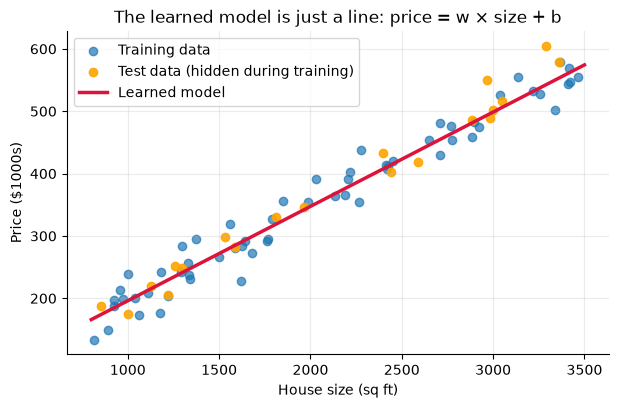

In [2]:
# ── Helper: create house price data for this section ────────────────────────
def making_data_for_intro():
    """
    Returns train/test splits for predicting house price from square footage.
      - Feature X: size of the house in square feet (800 to 3500)
      - Target  y: sale price in thousands of dollars
    The true relationship is roughly: price = 0.15 * size + 50, plus some random noise.
    """
    rng = np.random.RandomState(42)
    size  = rng.uniform(800, 3500, 80)                    # 80 houses
    price = 0.15 * size + 50 + rng.normal(0, 25, 80)      # price in $1000s, with noise
    X = size.reshape(-1, 1)                               # sklearn wants X as a 2-D table
    return train_test_split(X, price, test_size=0.25, random_state=42)

# Step 1-2: get data and split it
X_train, X_test, y_train, y_test = making_data_for_intro()

# Step 3-4: choose a model and train it
model = LinearRegression()
model.fit(X_train, y_train)          # "fit" = learn the parameters from the training data

# Step 5: evaluate on data the model has never seen
test_mae = mean_absolute_error(y_test, model.predict(X_test))

print(f"Learned slope (w):     {model.coef_[0]:.3f}  -> each extra sq ft adds about ${model.coef_[0]*1000:,.0f}")
print(f"Learned intercept (b): {model.intercept_:.1f}  -> baseline price of ${model.intercept_*1000:,.0f}")
print(f"Test MAE:              ${test_mae*1000:,.0f}  -> typical prediction error on unseen houses")

# Step 6: predict for a brand-new house
new_house = np.array([[2000]])
print(f"\nPredicted price for a 2,000 sq ft house: ${model.predict(new_house)[0]*1000:,.0f}")

# Plot
plt.figure(figsize=(7, 4.2))
plt.scatter(X_train, y_train, label='Training data', alpha=0.7)
plt.scatter(X_test,  y_test,  label='Test data (hidden during training)', color='orange', alpha=0.9)
xs = np.linspace(800, 3500, 100).reshape(-1, 1)
plt.plot(xs, model.predict(xs), color='crimson', lw=2.5, label='Learned model')
plt.xlabel('House size (sq ft)'); plt.ylabel('Price ($1000s)')
plt.title('The learned model is just a line: price = w × size + b'); plt.legend()
plt.show()

The "model" we just trained is nothing mystical: it is a line with two **parameters**, a slope and an intercept.
**"Learning" simply meant finding the slope and intercept that fit the training data well.**
The rest of this chapter is about *how* that finding happens and *how to know whether it worked*.

> **Parameters vs. hyperparameters — don't mix them up!**
> * **Parameters** (slope, intercept) are *learned automatically* from the data.
> * **Hyperparameters** (tree depth, number of clusters, learning rate) are *chosen by you* before training.

---
# Part 2: Supervised vs. Unsupervised Learning

Machine learning tasks are organized by **whether the training data includes the correct answers**.

> **Everyday analogy:**
> * **Supervised learning** is studying with flashcards that have the answer on the back. You can check yourself.
> * **Unsupervised learning** is being handed a giant box of unlabeled photos and asked to sort them into piles
>   that "feel similar." Nobody tells you the right piles.

## 2.1 The Big Picture

| | **Supervised Learning** | **Unsupervised Learning** |
|---|---|---|
| **Training data has labels?** | ✅ Yes — features `X` **and** target `y` | ❌ No — features `X` only |
| **Goal** | Predict the target for new examples | Discover hidden structure or groups |
| **Main task types** | **Regression** (predict a number)<br>**Classification** (predict a category) | **Clustering** (find groups)<br>Dimensionality reduction (simplify many features into few) |
| **How do we grade it?** | Compare predictions to the known answers | No answer key — judged by usefulness / structure |
| **Example algorithms** | Linear regression, decision trees, random forests | K-Means, hierarchical clustering, PCA |
| **Example question** | "What will this house sell for?" | "What natural customer segments do we have?" |

### Which one do I need? A simple decision guide

```
Do you have a specific target column you want to predict?
 ├── YES → SUPERVISED
 │         ├── Is the target a NUMBER?    (price, temperature, minutes)  → REGRESSION
 │         └── Is the target a CATEGORY?  (spam/ham, cat/dog, rain/no)   → CLASSIFICATION
 └── NO  → UNSUPERVISED
           └── Want to find natural groups?                              → CLUSTERING
```

> **Other flavors (just so you've heard of them):** *Semi-supervised* learning uses a few labels plus lots of
> unlabeled data. *Reinforcement learning* learns from rewards and penalties while taking actions (think game-playing agents).
> We focus on supervised and unsupervised learning in this course.

---
## 2.2 Seeing the Difference

We'll use the *same* 2-D dataset two ways. In the **supervised** view the model sees the labels (the colors) while training.
In the **unsupervised** view the labels are removed, and the model has to find the groups by itself.

SUPERVISED   (classification): test accuracy = 100.0%  <- we can grade it, we know the answers
UNSUPERVISED (clustering):     found 3 groups  <- no answer key to grade against


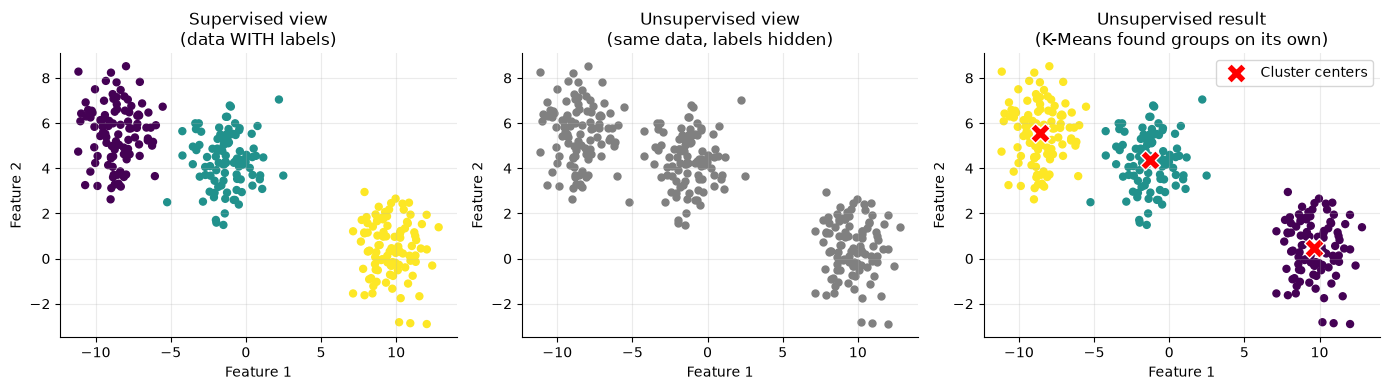

In [3]:
# ── Helper: create a simple 2-D dataset with 3 natural groups ───────────────
def making_data_for_learning_types():
    """
    Returns a 2-D dataset of 300 points that form 3 natural groups.
      - X: the two features for each point
      - y: the group each point truly belongs to (0, 1, or 2)
    Supervised learning gets to use y; unsupervised learning does NOT.
    """
    X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.3, random_state=7)
    return X, y

X, y = making_data_for_learning_types()

# ── SUPERVISED: classification, uses the labels y ───────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
clf = LogisticRegression().fit(X_tr, y_tr)      # learns from X AND y
print(f"SUPERVISED   (classification): test accuracy = {clf.score(X_te, y_te):.1%}  <- we can grade it, we know the answers")

# ── UNSUPERVISED: clustering, never sees y ──────────────────────────────────
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)   # learns from X only!
print(f"UNSUPERVISED (clustering):     found {len(set(km.labels_))} groups  <- no answer key to grade against")

# ── Plot the three views ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=25)
axes[0].set_title('Supervised view\n(data WITH labels)')
axes[1].scatter(X[:, 0], X[:, 1], c='gray', s=25)
axes[1].set_title('Unsupervised view\n(same data, labels hidden)')
axes[2].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', s=25)
axes[2].scatter(*km.cluster_centers_.T, c='red', marker='X', s=200, edgecolor='white', label='Cluster centers')
axes[2].set_title('Unsupervised result\n(K-Means found groups on its own)'); axes[2].legend()
for ax in axes: ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout(); plt.show()

Notice that K-Means recovered nearly the same three groups **without ever seeing the labels**.
Its cluster numbers (0, 1, 2) are arbitrary — "cluster 0" in one run may be "cluster 2" in another — and it has no
way to tell us what each group *means*. A human has to look at each group and interpret it.

### ✏️ Quick Check: Supervised or Unsupervised?

For each scenario, decide: supervised (regression or classification) or unsupervised (clustering)?

1. Predict tomorrow's high temperature from today's weather measurements.
2. Group a store's customers by their buying behavior, with no predefined categories.
3. Using past transactions labeled "fraud" or "legit", flag new fraudulent transactions.
4. Discover topics across 100,000 news articles that have no tags.
5. Predict a student's final exam score from hours studied.

<details>
<summary><b>Click for answers</b></summary>

1. **Supervised — regression** (the target is a number)
2. **Unsupervised — clustering** (no target column, we want natural groups)
3. **Supervised — classification** (the target is a category: fraud / legit)
4. **Unsupervised — clustering** (no labels exist)
5. **Supervised — regression** (the target is a number)
</details>

---
# Part 3: Loss Functions — Measuring How Wrong We Are

## 3.1 Why We Need a Loss Function

To *improve* a model, the computer needs a single number that says **"how bad are the current predictions?"**
That number is the **loss**, computed by a **loss function**. Lower loss = better model.

Training a model means: **find the parameters that make the loss as small as possible.**

```
1. Make predictions with the current parameters
2. Compute the loss (how wrong are we?)
3. Adjust the parameters to reduce the loss      ← gradient descent (Part 4)
4. Repeat
```

> **Loss vs. metric:** A *loss* is what a training algorithm tries to reduce. Gradient descent works most directly with
> differentiable losses; other algorithms can optimize losses that are not smooth. A *metric* is what humans report (like accuracy). They are often the
> same thing, but not always — we'll see why for classification below.

Let $y$ = the true value, $\hat{y}$ = the prediction, and $n$ = the number of examples.

---
## 3.2 Losses for Regression (Predicting a Number)

### **MAE** — Mean Absolute Error
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
The average size of the errors, ignoring direction. Every dollar of error counts the same.

### **MSE** — Mean Squared Error
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Squares each error first, so **big errors are punished much more than small ones**. This is the default loss for linear regression.

### **RMSE** — Root Mean Squared Error
$$\text{RMSE} = \sqrt{\text{MSE}}$$
MSE converted back to the original units (dollars instead of dollars²).

### **Huber Loss** — the best of both
$$L_\delta(e) = \begin{cases} \tfrac{1}{2}e^2 & \text{if } |e| \le \delta \\ \delta\left(|e| - \tfrac{1}{2}\delta\right) & \text{otherwise} \end{cases} \qquad \text{where } e = y - \hat{y}$$
Behaves like MSE for small errors (smooth) and like MAE for large errors (not overly sensitive to outliers).
$\delta$ is the cutoff you choose.

Let's compute these on a few house-price predictions (prices in $1000s), then see what happens when **one** prediction is wildly off.

In [4]:
# ── Helper: create house price predictions to compute losses on ─────────────
def making_data_for_loss():
    """
    Returns actual and predicted house prices (in $1000s) for 6 homes.
    Every prediction is off by a modest amount.
    """
    true_prices = np.array([250, 310, 180, 420, 365, 275])
    pred_prices = np.array([260, 290, 200, 400, 370, 270])
    return true_prices, pred_prices

def regression_losses(y_true, y_pred):
    """Compute MAE, MSE and RMSE by hand with numpy."""
    errors = y_true - y_pred
    mae  = np.mean(np.abs(errors))
    mse  = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    return mae, mse, rmse

true_prices, pred_prices = making_data_for_loss()

# ── Case 1: every prediction is a little off ────────────────────────────────
mae, mse, rmse = regression_losses(true_prices, pred_prices)
print("CASE 1: all errors are modest")
print(f"  errors = {true_prices - pred_prices}")
print(f"  MAE  = {mae:6.1f}   ($1000s)")
print(f"  MSE  = {mse:6.1f}   ($1000s squared)")
print(f"  RMSE = {rmse:6.1f}   ($1000s)")

# sanity check: sklearn gives the same answers
assert np.isclose(mae, mean_absolute_error(true_prices, pred_prices))
assert np.isclose(mse, mean_squared_error(true_prices, pred_prices))

# ── Case 2: the last prediction is wildly wrong (an outlier) ────────────────
bad_pred = pred_prices.copy()
bad_pred[-1] = 150            # predicted $150k for a $275k house
mae2, mse2, rmse2 = regression_losses(true_prices, bad_pred)
print("\nCASE 2: one prediction is way off")
print(f"  errors = {true_prices - bad_pred}")
print(f"  MAE  = {mae2:6.1f}   (went up {mae2/mae:.1f}x)")
print(f"  MSE  = {mse2:6.1f}   (went up {mse2/mse:.1f}x)")
print(f"  RMSE = {rmse2:6.1f}   (went up {rmse2/rmse:.1f}x)")
print(f"\nOne big mistake inflated MAE {mae2/mae:.1f}x but MSE {mse2/mse:.1f}x — squaring makes big errors dominate.")

CASE 1: all errors are modest
  errors = [-10  20 -20  20  -5   5]
  MAE  =   13.3   ($1000s)
  MSE  =  225.0   ($1000s squared)
  RMSE =   15.0   ($1000s)

CASE 2: one prediction is way off
  errors = [-10  20 -20  20  -5 125]
  MAE  =   33.3   (went up 2.5x)
  MSE  = 2825.0   (went up 12.6x)
  RMSE =   53.2   (went up 3.5x)

One big mistake inflated MAE 2.5x but MSE 12.6x — squaring makes big errors dominate.


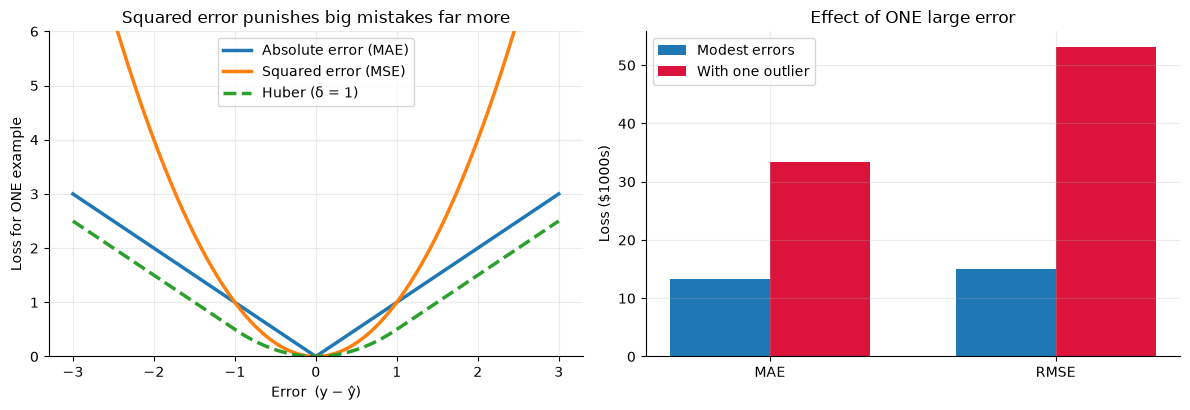

In [5]:
# ── Visualize: shape of each loss as a function of the error ────────────────
def huber(e, delta=1.0):
    return np.where(np.abs(e) <= delta, 0.5 * e**2, delta * (np.abs(e) - 0.5 * delta))

e = np.linspace(-3, 3, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: loss shape
axes[0].plot(e, np.abs(e), label='Absolute error (MAE)', lw=2.5)
axes[0].plot(e, e**2,      label='Squared error (MSE)',  lw=2.5)
axes[0].plot(e, huber(e),  label='Huber (δ = 1)',        lw=2.5, linestyle='--')
axes[0].set_ylim(0, 6); axes[0].set_xlabel('Error  (y − ŷ)'); axes[0].set_ylabel('Loss for ONE example')
axes[0].set_title('Squared error punishes big mistakes far more'); axes[0].legend()

# Right: effect of one outlier
labels = ['MAE', 'RMSE']
before = [mae, rmse]; after = [mae2, rmse2]
xpos = np.arange(2); w = 0.35
axes[1].bar(xpos - w/2, before, w, label='Modest errors')
axes[1].bar(xpos + w/2, after,  w, label='With one outlier', color='crimson')
axes[1].set_xticks(xpos); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Loss ($1000s)'); axes[1].set_title('Effect of ONE large error'); axes[1].legend()
plt.tight_layout(); plt.show()

### At a Glance — Regression Losses

| Loss | Penalizes big errors heavily? | Units | Smooth at 0? | Best when... |
|------|------------------------------|-------|--------------|--------------|
| **MAE** | No — all errors count equally | Same as data | No (sharp corner) | Your data has outliers you don't want to over-punish |
| **MSE** | Yes — very much so | Squared | Yes | Big mistakes are especially costly; the default for linear regression |
| **RMSE** | Yes — very much so | Same as data | Not always | You want MSE's behavior but need an easy-to-read number |
| **Huber** | Grows linearly beyond cutoff δ | Squared units with this definition | Yes | You want smooth optimization *and* outlier robustness |

---
## 3.3 Losses for Classification (Predicting a Category)

For classification the obvious metric is **accuracy** — the fraction of predictions that are correct. But accuracy makes a poor *training*
loss for two reasons:

1. **It ignores confidence.** A model that says "90% sure it's spam" and one that says "51% sure it's spam" both get full credit when right.
2. **It isn't smooth.** A prediction is either right or wrong, so tiny parameter changes usually don't change accuracy at all. That gives
   gradient descent nothing to follow (Part 4).

The standard fix is **log loss**, also called **binary cross-entropy**. The model outputs a *probability* $p$ that the example is in class 1:

$$\text{Log Loss} = -\frac{1}{n}\sum_{i=1}^{n}\Big[\, y_i \ln(p_i) + (1-y_i)\ln(1-p_i) \,\Big]$$

**Reading the formula:** if the true label is $y=1$, only the first term survives, giving $-\ln(p)$. If the true label is $y=0$,
only the second survives, giving $-\ln(1-p)$. In both cases: *the loss is small when the model put high probability on the correct answer, and huge when it was confidently wrong.*

| True label | Model's probability of class 1 | Loss for this example | Meaning |
|:---:|:---:|:---:|---|
| 1 | 0.99 | 0.01 | Confident and right → tiny loss |
| 1 | 0.70 | 0.36 | Right, but unsure → small loss |
| 1 | 0.50 | 0.69 | A coin flip |
| 1 | 0.10 | 2.30 | Wrong and fairly confident → big loss |
| 1 | 0.01 | 4.61 | Wrong and *very* confident → huge loss |

Let's see this in action: three models, same data. Two are always right but differ in confidence; the third is confident but wrong once.

Model                               Accuracy   Log Loss
-------------------------------------------------------
Model A (confident, right)            100.0%      0.068
Model B (right, but unsure)           100.0%      0.545
Model C (one confident mistake)        87.5%      0.550

A and B have IDENTICAL accuracy, but log loss tells them apart (A is much better).
C has only ONE wrong answer, yet its log loss jumps to about the level of the hedging Model B: overconfidence is costly.


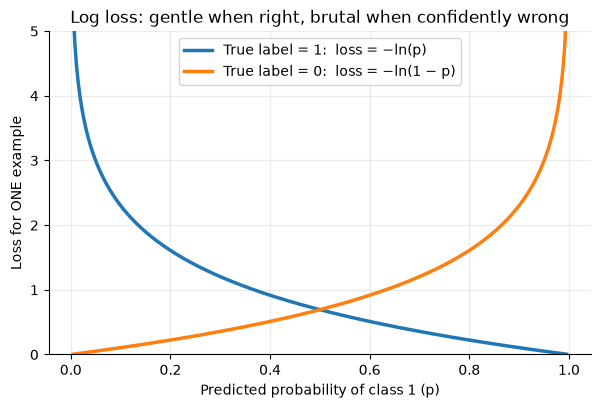

In [6]:
# ── Helper: create probabilities from three classifiers ─────────────────────
def making_data_for_log_loss():
    """
    Returns the true labels (1 = spam, 0 = ham) for 8 emails, and the predicted
    probability-of-spam from three different models.
    """
    y_true = np.array([1,    1,    1,    0,    0,    0,    1,    0   ])
    p_A    = np.array([0.95, 0.90, 0.92, 0.05, 0.10, 0.08, 0.97, 0.03])   # confident AND right
    p_B    = np.array([0.60, 0.55, 0.65, 0.45, 0.40, 0.48, 0.60, 0.42])   # right, but hedging
    p_C    = p_A.copy(); p_C[0] = 0.02                                     # confident but WRONG on email #1
    return y_true, {'Model A (confident, right)': p_A,
                    'Model B (right, but unsure)': p_B,
                    'Model C (one confident mistake)': p_C}

y_true, models = making_data_for_log_loss()

print(f"{'Model':<34} {'Accuracy':>9} {'Log Loss':>10}")
print("-" * 55)
for name, p in models.items():
    acc = accuracy_score(y_true, (p >= 0.5).astype(int))   # turn probability into a yes/no guess at 0.5
    ll  = log_loss(y_true, p)
    print(f"{name:<34} {acc:>9.1%} {ll:>10.3f}")

print("\nA and B have IDENTICAL accuracy, but log loss tells them apart (A is much better).")
print("C has only ONE wrong answer, yet its log loss jumps to about the level of the hedging Model B: overconfidence is costly.")

# ── Plot the log loss curves ────────────────────────────────────────────────
p = np.linspace(0.005, 0.995, 300)
plt.figure(figsize=(7, 4.2))
plt.plot(p, -np.log(p),     lw=2.5, label='True label = 1:  loss = −ln(p)')
plt.plot(p, -np.log(1 - p), lw=2.5, label='True label = 0:  loss = −ln(1 − p)')
plt.ylim(0, 5); plt.xlabel('Predicted probability of class 1 (p)'); plt.ylabel('Loss for ONE example')
plt.title('Log loss: gentle when right, brutal when confidently wrong'); plt.legend()
plt.show()

### Which Loss Should I Use?

| Problem type | Typical loss | Why |
|---|---|---|
| Regression, well-behaved data | **MSE** (report RMSE) | Smooth, standard, easy to optimize |
| Regression with outliers | **MAE** or **Huber** | Outliers don't dominate |
| Binary classification | **Log loss** (binary cross-entropy) | Rewards calibrated confidence; smooth |
| Multi-class classification | **Cross-entropy** | Log loss generalized to many classes |
| Clustering (K-Means) | **Within-cluster sum of squares** (inertia) | Squared distance of points to their cluster centers |

---
## 3.4 The Loss Landscape: Loss as a Function of the Parameters

Here is the key idea that connects loss functions to gradient descent. For a *fixed* dataset, the loss depends only on the model's
**parameters**. Change the slope of a line, and the MSE changes. If we plot loss against the parameter, we get a **loss landscape**,
and training means finding its lowest point.

We'll use a new house-price dataset for the rest of this chapter. We also **standardize** the feature (subtract the mean, divide by the standard deviation),
which makes gradient descent behave much better, as you'll see in Part 4.

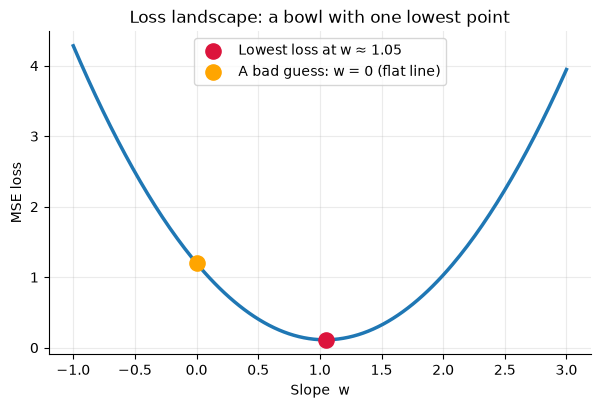

In [7]:
# ── Helper: create house price data for gradient descent ────────────────────
def making_data_for_gradient_descent():
    """
    Returns 60 houses:
      - size_k:    size in thousands of sq ft (0.8 to 3.5)
      - price_100k: sale price in hundreds of thousands of dollars
    True relationship: price = 0.5 + 1.5 * size, plus random noise.
    """
    rng = np.random.RandomState(0)
    size_k = rng.uniform(0.8, 3.5, 60)
    price_100k = 0.5 + 1.5 * size_k + rng.normal(0, 0.35, 60)
    return size_k, price_100k

size_k, price = making_data_for_gradient_descent()

# Standardize the feature: mean 0, standard deviation 1
x = (size_k - size_k.mean()) / size_k.std()
y = price

# Model: y_hat = w * x + b.  Fix b at the best value, and try many slopes w.
b_fixed = y.mean()                      # with a standardized x, the best intercept is just mean(y)
w_grid  = np.linspace(-1, 3, 200)
mse_grid = [np.mean((y - (w * x + b_fixed)) ** 2) for w in w_grid]

best_w = w_grid[np.argmin(mse_grid)]

plt.figure(figsize=(7, 4.2))
plt.plot(w_grid, mse_grid, lw=2.5)
plt.scatter([best_w], [min(mse_grid)], color='crimson', s=120, zorder=3, label=f'Lowest loss at w ≈ {best_w:.2f}')
plt.scatter([0], [np.mean((y - b_fixed) ** 2)], color='orange', s=120, zorder=3, label='A bad guess: w = 0 (flat line)')
plt.xlabel('Slope  w'); plt.ylabel('MSE loss')
plt.title('Loss landscape: a bowl with one lowest point'); plt.legend()
plt.show()

For linear regression with MSE, the landscape is a smooth **bowl**: one lowest point, and slopes that always point downhill toward it.

We *could* find the bottom by trying every possible slope, as we just did. But real models have thousands or millions of parameters,
and trying every combination is impossible. We need a smarter way to walk downhill. That is **gradient descent**.

---
# Part 4: Gradient Descent — Learning by Walking Downhill

## 4.1 The Main Idea ⛰️

> **Everyday analogy:** You're standing on a foggy mountain and want to reach the valley, but you can only feel the ground
> right under your feet. Strategy: feel which direction slopes downward most steeply, take a step that way, and repeat.
> You never see the whole mountain, yet you reliably end up at the bottom.

That's **gradient descent**:
* The **mountain** is the loss landscape (Part 3.4).
* Your **position** is the current set of parameters.
* The **slope under your feet** is the **gradient**: the derivative of the loss with respect to each parameter.
* The gradient points *uphill*, so we step in the **opposite** direction.

### The Update Rule

$$\theta_{\text{new}} = \theta_{\text{old}} - \alpha \cdot \frac{\partial L}{\partial \theta}$$

* $\theta$ = a parameter (like the slope $w$)
* $\frac{\partial L}{\partial \theta}$ = the gradient: how fast the loss changes if we nudge $\theta$
* $\alpha$ (alpha) = the **learning rate**: how big a step we take

```
1. Start with a guess for the parameters
2. Compute the loss and the gradient
3. Update every parameter:  θ ← θ − α × gradient
4. Repeat until the loss stops decreasing
```

Before applying this to a model, let's watch it work on the simplest possible "mountain": $L(w) = (w - 3)^2$, whose lowest point is at $w = 3$.
Its gradient is $2(w-3)$. We'll try three different learning rates.

α = 0.02  -> after 15 steps, w =    0.290   (target is 3.0)
α = 0.3   -> after 15 steps, w =    3.000   (target is 3.0)
α = 1.05  -> after 15 steps, w =   23.886   (target is 3.0)


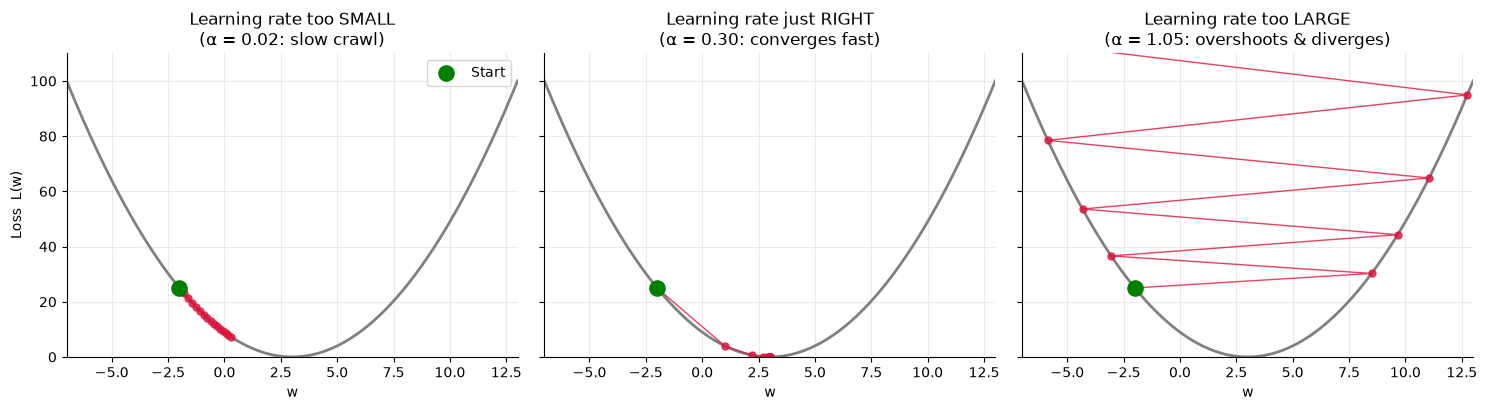

In [8]:
# ── Gradient descent on a simple 1-D bowl: L(w) = (w - 3)^2 ─────────────────
def gd_1d(lr, n_steps=15, start=-2.0):
    """Run gradient descent on L(w) = (w-3)^2 and return every w visited."""
    w = start
    path = [w]
    for _ in range(n_steps):
        gradient = 2 * (w - 3)       # derivative of (w-3)^2
        w = w - lr * gradient        # THE update rule
        path.append(w)
    return np.array(path)

settings = [(0.02, 'Learning rate too SMALL\n(α = 0.02: slow crawl)'),
            (0.30, 'Learning rate just RIGHT\n(α = 0.30: converges fast)'),
            (1.05, 'Learning rate too LARGE\n(α = 1.05: overshoots & diverges)')]

wide = np.linspace(-7, 13, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (lr, title) in zip(axes, settings):
    path = gd_1d(lr)
    ax.plot(wide, (wide - 3) ** 2, color='gray', lw=2)
    ax.plot(path, (path - 3) ** 2, 'o-', color='crimson', ms=5, lw=1, alpha=0.8)
    ax.scatter(path[0], (path[0] - 3) ** 2, color='green', s=120, zorder=4, label='Start')
    ax.set_title(title); ax.set_xlabel('w'); ax.set_ylim(0, 110); ax.set_xlim(-7, 13)
    print(f"α = {lr:<5} -> after 15 steps, w = {path[-1]:8.3f}   (target is 3.0)")
axes[0].set_ylabel('Loss  L(w)'); axes[0].legend()
plt.tight_layout(); plt.show()

### Key Parameters — Gradient Descent

| Parameter | What it does | Effect of changing it |
|-----------|-------------|----------------------|
| **Learning rate** (`α`, `lr`) | Size of each step | **Too small:** painfully slow. **Too large:** overshoots the bottom, may bounce around or blow up (diverge). The most important setting to tune. |
| **Number of steps** (`n_steps`, a.k.a. iterations or epochs) | How many updates to run | Too few: stops before reaching the bottom. Too many: wasted time once converged. |
| **Starting point** | Initial parameter values | For a bowl-shaped loss, it doesn't matter. For complicated landscapes, it can decide which valley you land in. |
| **Batch size** | How many examples are used to compute each gradient *(see 4.4)* | Smaller = faster steps but noisier; larger = smoother but slower. |

> **Rule of thumb:** If your loss is going **up** or jumping around wildly, lower the learning rate. If it's decreasing but painfully slowly, raise it.

---
## 4.2 Gradient Descent for Linear Regression

Now let's use it to train a real model: $\hat{y} = w\,x + b$ with **MSE loss**:

$$L(w, b) = \frac{1}{n}\sum_{i=1}^{n}\big(y_i - (w x_i + b)\big)^2$$

We have two parameters, so we need two gradients (these come from the chain rule):

$$\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^{n} x_i\,\big(y_i - \hat{y}_i\big) \qquad\qquad \frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n} \big(y_i - \hat{y}_i\big)$$

**Sanity check on the intuition:** if the model predicts too low ($y_i > \hat{y}_i$) for large-$x$ houses, the gradient for $w$ is negative, so
$w \leftarrow w - \alpha \cdot (\text{negative})$ **increases** $w$. That is exactly the correction we want.

Let's code it from scratch and compare it with scikit-learn.

In [9]:
def gradient_descent(x, y, lr=0.1, n_steps=50, w=0.0, b=0.0, batch_size=None, seed=0):
    """
    Train y_hat = w*x + b with MSE loss using gradient descent.

    lr         : learning rate (step size)
    n_steps    : number of parameter updates
    w, b       : starting values for the parameters
    batch_size : None = use ALL data for each step ("batch" gradient descent)
                 k    = use k random examples per step (mini-batch / stochastic)
    Returns a dict with the full history of w, b, and the loss on the full dataset.
    """
    rng = np.random.RandomState(seed)
    n = len(x)
    history = {'w': [w], 'b': [b], 'loss': [np.mean((y - (w * x + b)) ** 2)]}

    for _ in range(n_steps):
        # pick which examples to use for this step
        idx = np.arange(n) if batch_size is None else rng.choice(n, batch_size, replace=False)
        xb, yb = x[idx], y[idx]

        error = yb - (w * xb + b)              # y - y_hat
        grad_w = -2 * np.mean(xb * error)      # dL/dw
        grad_b = -2 * np.mean(error)           # dL/db

        w = w - lr * grad_w                    # update rule
        b = b - lr * grad_b

        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(np.mean((y - (w * x + b)) ** 2))   # always track loss on ALL data
    return history

# ── Train with gradient descent ─────────────────────────────────────────────
hist = gradient_descent(x, y, lr=0.1, n_steps=50)

print(f"{'Step':>5} {'w':>8} {'b':>8} {'Loss (MSE)':>12}")
print("-" * 38)
for step in [0, 1, 2, 5, 10, 20, 50]:
    print(f"{step:>5} {hist['w'][step]:>8.3f} {hist['b'][step]:>8.3f} {hist['loss'][step]:>12.4f}")

# ── Compare with scikit-learn's exact solution ──────────────────────────────
sk = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"\nGradient descent:  w = {hist['w'][-1]:.4f},  b = {hist['b'][-1]:.4f}")
print(f"scikit-learn:      w = {sk.coef_[0]:.4f},  b = {sk.intercept_:.4f}")
print("They match! sklearn solves it directly with algebra; gradient descent got there by walking downhill.")

 Step        w        b   Loss (MSE)
--------------------------------------
    0    0.000    0.000      15.6706
    1    0.208    0.761      10.0695
    2    0.375    1.370       6.4848
    5    0.701    2.558       1.7826
   10    0.930    3.396       0.2914
   20    1.030    3.760       0.1141
   50    1.042    3.804       0.1120

Gradient descent:  w = 1.0420,  b = 3.8043
scikit-learn:      w = 1.0420,  b = 3.8043
They match! sklearn solves it directly with algebra; gradient descent got there by walking downhill.


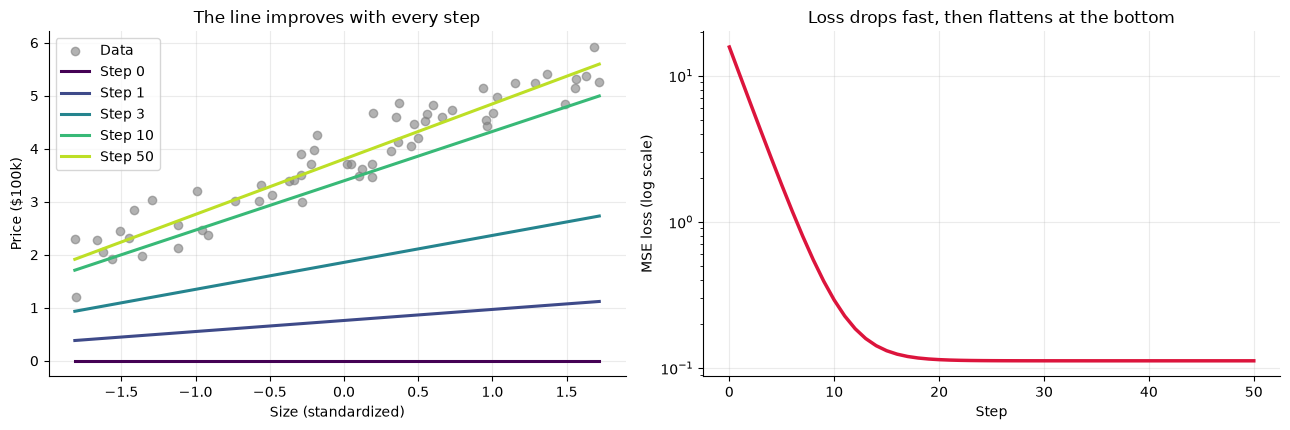

In [10]:
# ── Visualize: the line improving, and the loss falling ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

steps_to_show = [0, 1, 3, 10, 50]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(steps_to_show)))
axes[0].scatter(x, y, alpha=0.6, color='gray', label='Data')
xs = np.linspace(x.min(), x.max(), 50)
for s, c in zip(steps_to_show, colors):
    axes[0].plot(xs, hist['w'][s] * xs + hist['b'][s], color=c, lw=2.2, label=f'Step {s}')
axes[0].set_xlabel('Size (standardized)'); axes[0].set_ylabel('Price ($100k)')
axes[0].set_title('The line improves with every step'); axes[0].legend()

axes[1].plot(hist['loss'], lw=2.5, color='crimson')
axes[1].set_yscale('log')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('MSE loss (log scale)')
axes[1].set_title('Loss drops fast, then flattens at the bottom')
plt.tight_layout(); plt.show()

### Two Parameters = A 3-D Bowl (viewed from above)

With both $w$ and $b$ free, the loss landscape is a 3-D bowl. The plot below shows it from above as a **contour map**: rings are lines of equal loss,
and the center is the minimum. Each dot is one gradient descent step. Compare a good learning rate with one that is too aggressive.

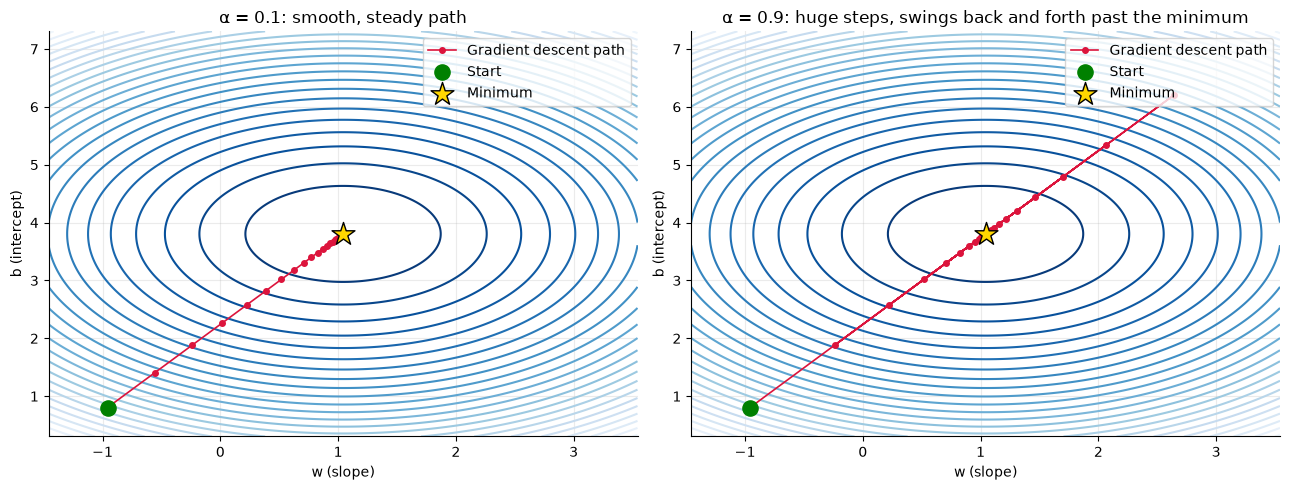

In [11]:
# ── Loss landscape in (w, b) with gradient-descent paths on top ─────────────
w_star, b_star = sk.coef_[0], sk.intercept_
W, B = np.meshgrid(np.linspace(w_star - 2.5, w_star + 2.5, 200),
                   np.linspace(b_star - 3.5, b_star + 3.5, 200))
LOSS = np.array([[np.mean((y - (w * x + b)) ** 2) for w in W[0]] for b in B[:, 0]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, lr, title in zip(axes, [0.1, 0.9],
                         ['α = 0.1: smooth, steady path', 'α = 0.9: huge steps, swings back and forth past the minimum']):
    h = gradient_descent(x, y, lr=lr, n_steps=25, w=w_star - 2.0, b=b_star - 3.0)
    ax.contour(W, B, LOSS, levels=25, cmap='Blues_r')
    ax.plot(h['w'], h['b'], 'o-', color='crimson', ms=4, lw=1.2, label='Gradient descent path')
    ax.scatter(h['w'][0], h['b'][0], color='green', s=120, zorder=4, label='Start')
    ax.scatter(w_star, b_star, color='gold', marker='*', s=300, edgecolor='black', zorder=5, label='Minimum')
    ax.set_xlabel('w (slope)'); ax.set_ylabel('b (intercept)'); ax.set_title(title); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

Both runs reach the minimum, but the second wastes effort bouncing back and forth. Push the learning rate higher still and it would never settle.
Let's confirm that with a direct comparison of three learning rates on this real regression problem.

lr = 0.01  -> loss after 50 steps: 2.175
lr = 0.1   -> loss after 50 steps: 0.112
lr = 1.05  -> loss after 50 steps: 2.144e+05


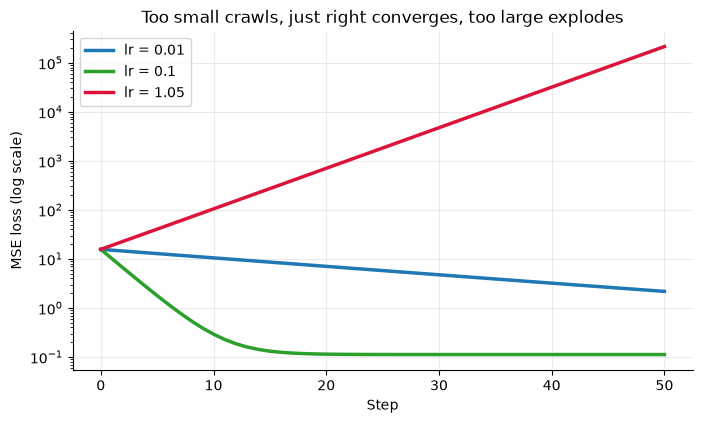

In [12]:
# ── Effect of learning rate on the regression problem ───────────────────────
fig, ax = plt.subplots(figsize=(8, 4.4))
for lr, color in [(0.01, 'tab:blue'), (0.1, 'tab:green'), (1.05, 'crimson')]:
    h = gradient_descent(x, y, lr=lr, n_steps=50)
    ax.plot(h['loss'], lw=2.5, color=color, label=f'lr = {lr}')
    print(f"lr = {lr:<5} -> loss after 50 steps: {h['loss'][-1]:.4g}")
ax.set_yscale('log'); ax.set_xlabel('Step'); ax.set_ylabel('MSE loss (log scale)')
ax.set_title('Too small crawls, just right converges, too large explodes'); ax.legend()
plt.show()

### 🔧 Why We Standardized the Feature

Gradient descent is sensitive to the **scale** of your features. If a feature takes huge values (like house size in raw square feet, 800 to 3500), a tiny change in the slope `w`
swings the loss enormously, while the intercept `b` barely matters. The loss landscape becomes a long, narrow canyon instead of a round bowl.
To avoid overshooting across the canyon you are forced to use an extremely tiny learning rate, and then progress *along* the canyon floor is glacial.
Let's run the same algorithm on the raw square footage to see it.

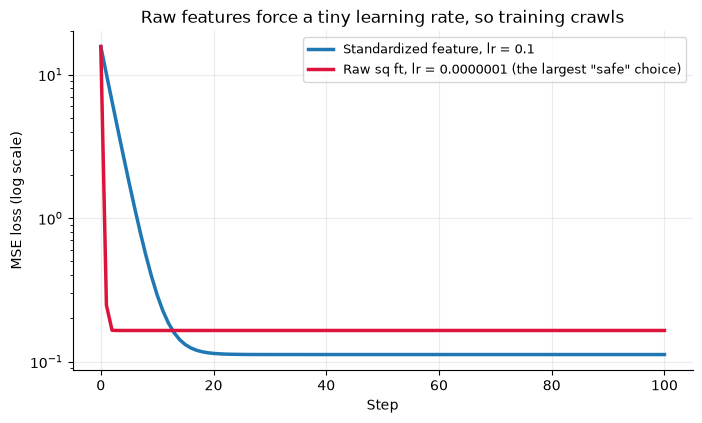

Best possible loss (sklearn):                    0.1120
Standardized, lr = 0.1, after 100 steps:         0.1120
Raw sq ft, lr = 1e-7, after 100 steps:           0.1648   <- still not converged
Raw sq ft, SAME lr = 0.1, after just 5 steps:    3.13e+61   <- diverged


In [13]:
# ── Same algorithm: standardized feature vs. raw square footage ─────────────
sqft = size_k * 1000                                          # raw feature: 800 to 3500 sq ft

h_std  = gradient_descent(x,    y, lr=0.1,  n_steps=100)     # standardized feature, lr = 0.1
h_tiny = gradient_descent(sqft, y, lr=1e-7, n_steps=100)     # raw sq ft: only a TINY lr is safe
h_same = gradient_descent(sqft, y, lr=0.1,  n_steps=5)       # raw sq ft with the SAME lr = 0.1

plt.figure(figsize=(8, 4.4))
plt.plot(h_std['loss'],  lw=2.5, label='Standardized feature, lr = 0.1')
plt.plot(h_tiny['loss'], lw=2.5, color='crimson', label='Raw sq ft, lr = 0.0000001 (the largest "safe" choice)')
plt.yscale('log'); plt.xlabel('Step'); plt.ylabel('MSE loss (log scale)')
plt.title('Raw features force a tiny learning rate, so training crawls'); plt.legend(fontsize=9)
plt.show()

best = float(np.mean((y - sk.predict(x.reshape(-1, 1))) ** 2))
print(f"Best possible loss (sklearn):                    {best:.4f}")
print(f"Standardized, lr = 0.1, after 100 steps:         {h_std['loss'][-1]:.4f}")
print(f"Raw sq ft, lr = 1e-7, after 100 steps:           {h_tiny['loss'][-1]:.4f}   <- still not converged")
print(f"Raw sq ft, SAME lr = 0.1, after just 5 steps:    {h_same['loss'][-1]:.3g}   <- diverged")

> **Takeaway:** Standardizing numeric features often makes gradient descent easier to tune, especially when features have very different scales. Fit the scaling transformation on training data, then apply that same transformation to validation and test data.
> Tree-based models generally do not need feature scaling because they split on feature thresholds.

---
## 4.3 Variants: Batch, Stochastic, and Mini-Batch

Our function computed each gradient using **all** the data. That's fine for 60 houses, but with millions of rows it's very slow. The fix: estimate the gradient from a **random subset** at each step.

| Variant | Data used per step | Speed per step | Path | Typical use |
|---|---|---|---|---|
| **Batch GD** | All $n$ examples | Slowest | Smooth, direct | Small datasets |
| **Stochastic GD (SGD)** | 1 random example | Fastest | Very noisy — jitters around | Streaming / huge data |
| **Mini-Batch GD** | A small batch (e.g., 32–256) | Fast | Mildly noisy | **The standard choice**, especially in deep learning |

The noise isn't all bad: it's cheap, and it can help escape bad spots on complicated landscapes. The `batch_size` argument of our function already supports all three.

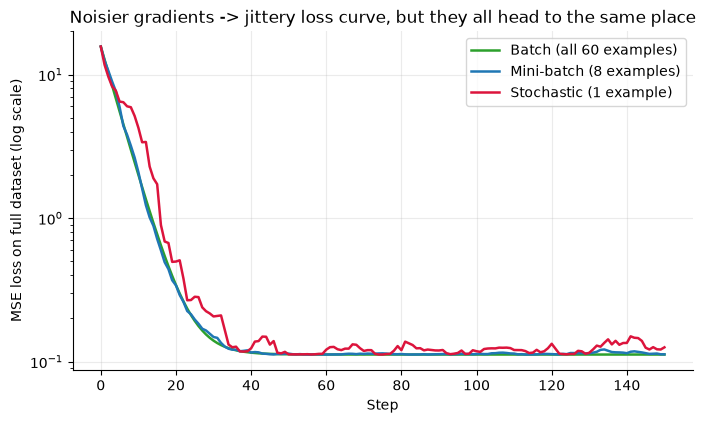

In [14]:
# ── Compare batch, mini-batch, and stochastic gradient descent ──────────────
fig, ax = plt.subplots(figsize=(8, 4.4))
configs = [(None, 'Batch (all 60 examples)', 'tab:green'),
           (8,    'Mini-batch (8 examples)', 'tab:blue'),
           (1,    'Stochastic (1 example)',  'crimson')]
for bs, label, color in configs:
    h = gradient_descent(x, y, lr=0.05, n_steps=150, batch_size=bs, seed=1)
    ax.plot(h['loss'], lw=1.8, color=color, label=label)
ax.set_yscale('log'); ax.set_xlabel('Step'); ax.set_ylabel('MSE loss on full dataset (log scale)')
ax.set_title('Noisier gradients -> jittery loss curve, but they all head to the same place'); ax.legend()
plt.show()

> **Looking ahead:** Modern deep learning uses smarter relatives of gradient descent, like **Adam**, which automatically adapts the learning rate for each parameter.
> They are all built on the same core idea you just implemented: *compute the gradient of the loss, step the opposite way.*

> **Looking ahead:** Tree-based models use different training algorithms. Their behavior can still be evaluated with the same ideas of loss, generalization, and bias versus variance.

---
# Part 5: Bias and Variance — Why Models Fail

## 5.1 Two Ways to Be Wrong

Suppose you could train the *same kind* of model on many different random training sets drawn from the same population. The model's predictions would differ a bit each time. Two things can go wrong:

* **Bias** — The model is systematically **off-target** because it is too simple to capture the real pattern. Even averaged over many training sets, it misses.
  (Fitting a straight line to a curved pattern.)
* **Variance** — The model is **unstable**: its predictions swing wildly depending on which training set it happened to see, because it is so flexible that it memorizes the quirks and noise of each one.
  (A wiggly curve that threads through every training point.)

> **Everyday analogy — archery.** The bullseye is the true answer. Each arrow is the prediction from a model trained on a different dataset.
> * *Low bias, low variance:* arrows tightly clustered on the bullseye. 🎯 (the goal)
> * *High bias, low variance:* arrows tightly clustered, but off to one side. Consistently wrong.
> * *Low bias, high variance:* arrows centered on the bullseye on average, but scattered everywhere.
> * *High bias, high variance:* scattered **and** off-center. The worst of both.

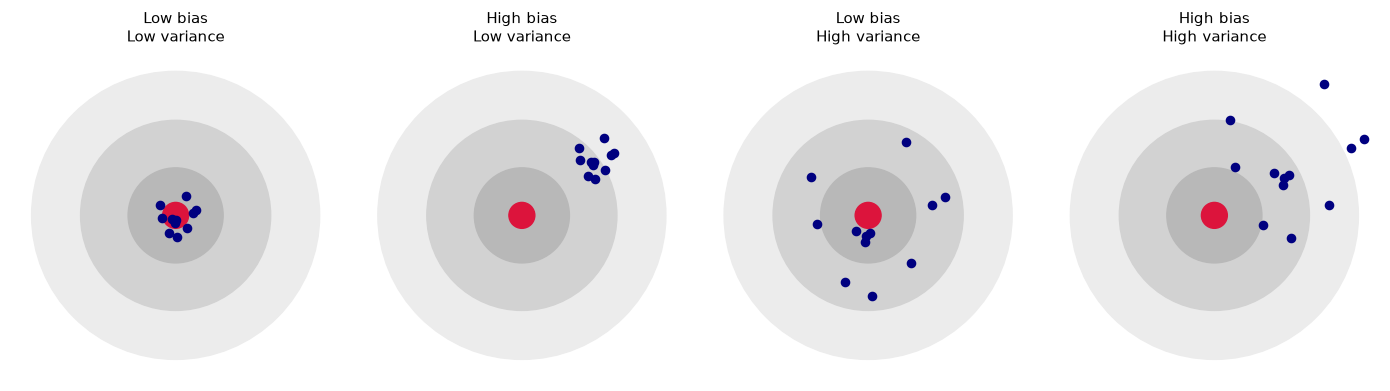

In [15]:
# ── Draw the archery analogy ────────────────────────────────────────────────
def draw_target(ax, offset, spread, title, seed=3):
    rng = np.random.RandomState(seed)
    for r, c in zip([1.0, 0.66, 0.33], ['#ececec', '#d2d2d2', '#b8b8b8']):
        ax.add_patch(plt.Circle((0, 0), r, color=c, zorder=1))
    ax.add_patch(plt.Circle((0, 0), 0.09, color='crimson', zorder=2))
    pts = np.array(offset) + rng.randn(12, 2) * spread
    ax.scatter(pts[:, 0], pts[:, 1], c='navy', s=35, zorder=3)
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect('equal')
    ax.axis('off'); ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
draw_target(axes[0], (0.0, 0.0), 0.08, 'Low bias\nLow variance')
draw_target(axes[1], (0.5, 0.4), 0.08, 'High bias\nLow variance')
draw_target(axes[2], (0.0, 0.0), 0.30, 'Low bias\nHigh variance')
draw_target(axes[3], (0.5, 0.4), 0.30, 'High bias\nHigh variance')
plt.tight_layout(); plt.show()

### The Bias–Variance Decomposition

For squared-error loss, a model's expected error on new data splits cleanly into three pieces:

$$\mathbb{E}\big[(y - \hat{f}(x))^2\big] \;=\; \underbrace{\text{Bias}^2}_{\text{too simple}} \;+\; \underbrace{\text{Variance}}_{\text{too sensitive to the training set}} \;+\; \underbrace{\sigma^2}_{\text{irreducible noise}}$$

* **Bias²** — how far the *average* prediction (over many training sets) is from the truth.
* **Variance** — how much predictions *vary around that average* from one training set to another.
* **Irreducible error ($\sigma^2$)** — randomness in the data itself. No model, however good, can remove it.

### The Tradeoff

Increasing **model complexity** (more flexible curves, deeper trees, more features) generally **lowers bias but raises variance**. Decreasing it does the opposite.
You can't minimize both at once, so the goal is the **sweet spot** where total error is lowest.

| | **High Bias** (Underfitting) | **High Variance** (Overfitting) |
|---|---|---|
| **Model is...** | Too simple | Too complex / flexible |
| **Training error** | High | Very low |
| **Test error** | High (≈ training error) | Much higher than training error |
| **Example** | A straight line through curved data | A degree-15 polynomial through 30 points |
| **Everyday analogy** | Studying only chapter 1 for the whole exam | Memorizing the practice problems word-for-word |

---
## 5.2 Watching Bias and Variance Happen

We can *measure* bias and variance directly if we know the truth. Our setup: the true pattern is a sine wave, and every data point has random noise added. We'll repeat the following 300 times:

1. Draw a fresh random training set of 40 points.
2. Fit a polynomial model.

Then we'll overlay the fitted curves (the plot shows 60 of them so it stays readable). We'll compare three model complexities: a degree-1 polynomial (a line), degree 3, and degree 8.

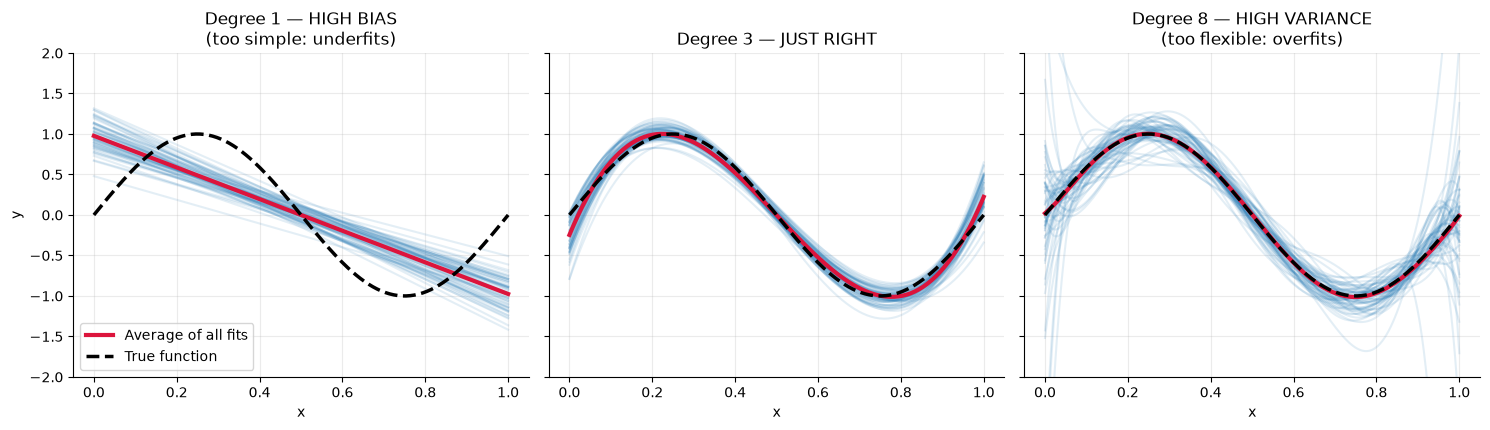

In [16]:
# ── Helpers for the bias-variance experiment ────────────────────────────────
NOISE_SD = 0.3                                     # standard deviation of the random noise
true_function = lambda x: np.sin(2 * np.pi * x)    # the hidden truth we're trying to learn

def making_data_for_bias_variance(n=40, seed=0):
    """
    Returns one random training set: n points x in [0,1], with y = sin(2*pi*x) + noise.
    Different seeds give different training sets from the same underlying truth.
    """
    rng = np.random.RandomState(seed)
    x = rng.rand(n)
    y = true_function(x) + rng.randn(n) * NOISE_SD
    return x.reshape(-1, 1), y

def polynomial_model(degree):
    """A polynomial regression model. Higher degree = more flexible (more complex)."""
    return make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())

x_grid = np.linspace(0, 1, 200).reshape(-1, 1)     # where we will measure predictions
truth  = true_function(x_grid).ravel()             # the true values at those points

def fit_many_models(degree, n=40, n_datasets=300):
    """Fit the same model type on many different training sets. Returns predictions on x_grid."""
    preds = []
    for seed in range(n_datasets):
        X_s, y_s = making_data_for_bias_variance(n, seed)
        preds.append(polynomial_model(degree).fit(X_s, y_s).predict(x_grid))
    return np.array(preds)                          # shape: (n_datasets, 200)

def bias_variance(preds):
    """
    Estimate Bias² and Variance from many fitted models' predictions (rows = different training sets).
      Variance = how much the predictions spread around their own average
      Bias²    = how far that average prediction is from the truth
    (The average of a finite number of fits still carries a little leftover noise,
     about Variance / n_datasets, so we subtract it. Values too small to measure reliably are floored at 0.0001.)
    """
    variance = preds.var(axis=0, ddof=1).mean()
    bias_sq  = np.mean((preds.mean(axis=0) - truth) ** 2) - variance / len(preds)
    return max(bias_sq, 1e-4), variance

# ── Plot: 100 fitted curves for each model complexity ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
titles = {1: 'Degree 1 — HIGH BIAS\n(too simple: underfits)',
          3: 'Degree 3 — JUST RIGHT',
          8: 'Degree 8 — HIGH VARIANCE\n(too flexible: overfits)'}
for ax, degree in zip(axes, [1, 3, 8]):
    preds = fit_many_models(degree)
    for p in preds[:60]:
        ax.plot(x_grid, p, color='tab:blue', alpha=0.12)
    ax.plot(x_grid, preds.mean(axis=0), color='crimson', lw=3, label='Average of all fits')
    ax.plot(x_grid, true_function(x_grid), 'k--', lw=2.5, label='True function')
    ax.set_ylim(-2, 2); ax.set_title(titles[degree]); ax.set_xlabel('x')
axes[0].set_ylabel('y'); axes[0].legend(loc='lower left')
plt.tight_layout(); plt.show()

**How to read this plot:** each faint blue curve is a model trained on a different random dataset.

* **Degree 1 (left):** the curves are nearly identical to each other (**low variance**), but their average (red) is far from the true sine wave (**high bias**). A line simply can't bend enough.
* **Degree 3 (middle):** the curves are tightly grouped *and* the average hugs the truth. This is the sweet spot.
* **Degree 8 (right):** the average (red) is close to the truth (**low bias**), but individual curves go wild (**high variance**), especially near the edges. Each fit is chasing the noise in its own training set.

Now let's put numbers on it and sweep through many complexities.

Degree      Bias²   Variance   Noise σ²  Total error
------------------------------------------------------
     1     0.2000     0.0178     0.0900       0.3078
     2     0.2011     0.0380     0.0900       0.3291
     3     0.0048     0.0115     0.0900       0.1063
     4     0.0051     0.0176     0.0900       0.1127
     5     0.0001     0.0240     0.0900       0.1141
     6     0.0001     0.0363     0.0900       0.1264
     7     0.0001     0.1098     0.0900       0.1999
     8     0.0001     0.2611     0.0900       0.3512
     9     0.0001     0.3973     0.0900       0.4874


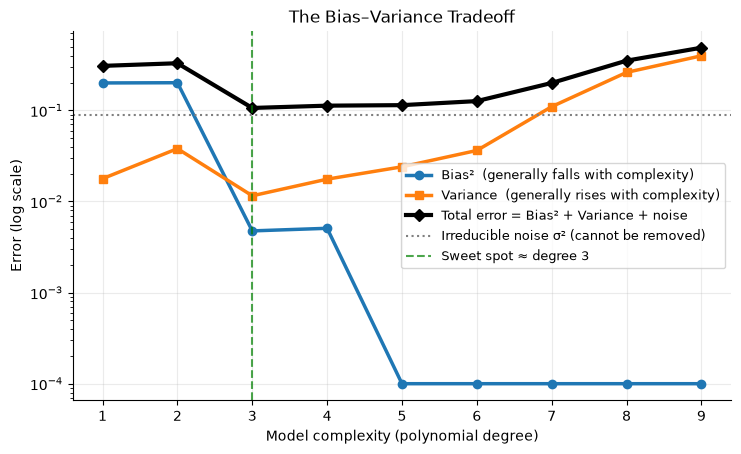

In [17]:
# ── Compute Bias² and Variance numerically for degrees 1 to 9 ───────────────
degrees = range(1, 10)
rows = []
for d in degrees:
    preds = fit_many_models(d)                           # (300 fits) x (200 grid points)
    bias_sq, variance = bias_variance(preds)             # Bias² and Variance from those fits
    rows.append((d, bias_sq, variance, bias_sq + variance + NOISE_SD ** 2))

print(f"{'Degree':>6} {'Bias²':>10} {'Variance':>10} {'Noise σ²':>10} {'Total error':>12}")
print("-" * 54)
for d, b2, v, tot in rows:
    print(f"{d:>6} {b2:>10.4f} {v:>10.4f} {NOISE_SD**2:>10.4f} {tot:>12.4f}")

deg  = [r[0] for r in rows]; b2 = [r[1] for r in rows]
var_ = [r[2] for r in rows]; tot = [r[3] for r in rows]
best_degree = deg[int(np.argmin(tot))]

plt.figure(figsize=(8.5, 4.8))
plt.plot(deg, b2,   'o-', lw=2.5, label='Bias²  (generally falls with complexity)')
plt.plot(deg, var_, 's-', lw=2.5, label='Variance  (generally rises with complexity)')
plt.plot(deg, tot,  'D-', lw=3,   color='black', label='Total error = Bias² + Variance + noise')
plt.axhline(NOISE_SD ** 2, color='gray', ls=':', label='Irreducible noise σ² (cannot be removed)')
plt.axvline(best_degree, color='green', ls='--', alpha=0.7, label=f'Sweet spot ≈ degree {best_degree}')
plt.yscale('log'); plt.xlabel('Model complexity (polynomial degree)'); plt.ylabel('Error (log scale)')
plt.title('The Bias–Variance Tradeoff'); plt.legend(fontsize=9)
plt.show()

This is the classic picture. Moving right (more complex), bias² shrinks, variance grows, and total error is U-shaped. The total can never drop below the gray dotted line — the **irreducible noise**.

*(Bias² for the flexible models is essentially zero, so it sits at our measurement floor of 0.0001. Variance is what grows.)*

> ⚠️ **A caveat:** We could compute bias and variance only because *we invented the true function*. In real projects the truth is unknown and we only have one dataset.
> So how do we diagnose the problem in practice? With the next tool.

---
## 5.3 Diagnosing Bias vs. Variance in Practice: Training vs. Validation Error

With a single dataset, we compare **training error** to **validation error** as complexity grows. We choose model complexity using validation data and reserve a separate test set for one final evaluation.
We'll use a smaller training set (25 points) so the effect is easy to see. The exact shape of the curves changes from dataset to dataset (try other `seed` values!),
but the overall pattern is reliable:

* Both high → **high bias** (underfitting).
* Training low, validation much higher → **high variance** (overfitting).

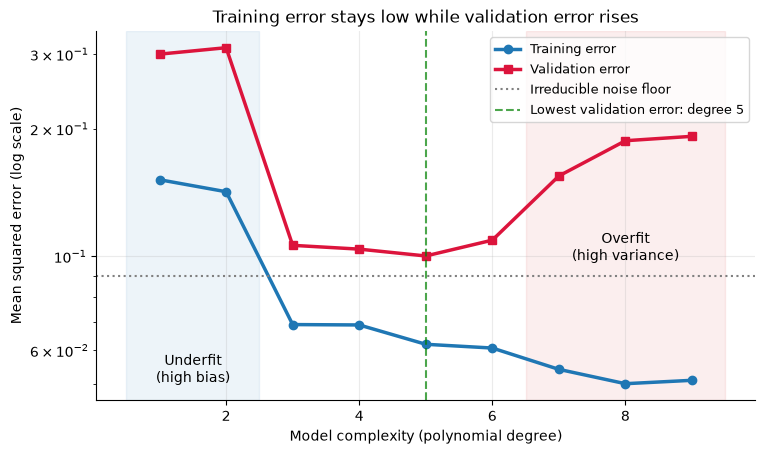

Degree 1: train MSE 0.152, validation MSE 0.300   -> high on both: UNDERFITTING
Degree 5: train MSE 0.062, validation MSE 0.100   -> selected on validation data
Degree 9: train MSE 0.051, validation MSE 0.192   -> large gap: OVERFITTING
Final test MSE for selected degree 5: 0.123   -> evaluated once after selection


In [18]:
# ── Select complexity using validation data; save test data for the end ──
X_tr, y_tr = making_data_for_bias_variance(n=25, seed=0)         # small training set
X_val, y_val = making_data_for_bias_variance(n=1000, seed=123) # validation set
X_te, y_te = making_data_for_bias_variance(n=1000, seed=999)   # final test set

train_err, val_err = [], []
for d in degrees:
    m = polynomial_model(d).fit(X_tr, y_tr)
    train_err.append(mean_squared_error(y_tr, m.predict(X_tr)))
    val_err.append(mean_squared_error(y_val, m.predict(X_val)))

best_d = list(degrees)[int(np.argmin(val_err))]
final_model = polynomial_model(best_d).fit(X_tr, y_tr)
final_test_err = mean_squared_error(y_te, final_model.predict(X_te))

plt.figure(figsize=(8.5, 4.8))
plt.plot(list(degrees), train_err, 'o-', lw=2.5, label='Training error')
plt.plot(list(degrees), val_err,  's-', lw=2.5, color='crimson', label='Validation error')
plt.axhline(NOISE_SD ** 2, color='gray', ls=':', label='Irreducible noise floor')
plt.axvline(best_d, color='green', ls='--', alpha=0.7, label=f'Lowest validation error: degree {best_d}')
ax = plt.gca()
plt.axvspan(0.5, 2.5, color='tab:blue', alpha=0.08); ax.text(1.5, 0.05, 'Underfit\n(high bias)',     ha='center', transform=ax.get_xaxis_transform())
plt.axvspan(6.5, 9.5, color='tab:red',  alpha=0.08); ax.text(8.0, 0.38, 'Overfit\n(high variance)', ha='center', transform=ax.get_xaxis_transform())
plt.yscale('log'); plt.xlabel('Model complexity (polynomial degree)'); plt.ylabel('Mean squared error (log scale)')
plt.title('Training error stays low while validation error rises'); plt.legend(fontsize=9)
plt.show()

print(f"Degree 1: train MSE {train_err[0]:.3f}, validation MSE {val_err[0]:.3f}   -> high on both: UNDERFITTING")
print(f"Degree {best_d}: train MSE {train_err[best_d-1]:.3f}, validation MSE {val_err[best_d-1]:.3f}   -> selected on validation data")
print(f"Degree 9: train MSE {train_err[8]:.3f}, validation MSE {val_err[8]:.3f}   -> large gap: OVERFITTING")
print(f"Final test MSE for selected degree {best_d}: {final_test_err:.3f}   -> evaluated once after selection")

**The most important lesson in this chapter:** *training error alone is a trap.* A very flexible model can fit training data closely while performing worse on new examples. Held-out validation data helps us choose complexity; the test set checks the final choice.

---
## 5.4 How to Fix It

| Diagnosis | Symptoms | Things to try |
|-----------|----------|---------------|
| **High bias** (underfitting) | Training and validation error both high | • Use a more flexible model (deeper tree, higher-degree polynomial)<br>• Add more or better features<br>• Reduce regularization |
| **High variance** (overfitting) | Training error low, validation error much higher | • Get more training data if possible<br>• Use a simpler model (limit `max_depth`, lower degree)<br>• Add regularization (Ridge / Lasso)<br>• Use ensembles that average many models (Random Forest)<br>• Remove noisy features |

More representative training data can reduce variance. We'll take the flexible degree-8 model from before and train it on 40 vs. 400 points per dataset.

In [19]:
# ── More data -> lower variance (same model, same complexity) ───────────────
print(f"{'Training set size':>18} {'Bias²':>10} {'Variance':>10}")
print("-" * 42)
for n in [40, 400]:
    bias_sq, variance = bias_variance(fit_many_models(degree=8, n=n))
    print(f"{n:>18} {bias_sq:>10.4f} {variance:>10.4f}")

print("\nThe model is exactly as flexible as before, but with 10x the data it can't be fooled by noise as easily:")
print("the variance decreases in this example because each fit has more representative training data.")

 Training set size      Bias²   Variance
------------------------------------------


                40     0.0001     0.2611


               400     0.0001     0.0022

The model is exactly as flexible as before, but with 10x the data it can't be fooled by noise as easily:
the variance decreases in this example because each fit has more representative training data.


### 🔗 Where This Tradeoff Appears

These ideas will return in later modeling chapters. For now, connect them to the examples in this notebook:

| Technique | What it does to bias / variance |
|-----------|--------------------------------|
| **Polynomial degree** | A line can underfit the curve; a high-degree polynomial can fit noise. |
| **More training data** | In our simulation, the degree-8 model becomes less sensitive to any single sample. |
| **Training/validation split** | Lets us compare model complexity on data that was not used for fitting. |
| **Decision-tree depth (later)** | Shallow trees can underfit; very deep trees can overfit. |

---
# Chapter Summary

Well done making it through the chapter! Here is a full recap:

---

### Introduction to Machine Learning
* ML = learning **rules (a model) from data** instead of hand-coding them.
* Workflow for supervised prediction: collect data → split train/validation/test → choose model → **train** → **select on validation data** → **evaluate once on test data** → predict.
* **Parameters** are learned from data; **hyperparameters** are chosen by you.

### Supervised vs. Unsupervised

| | Supervised | Unsupervised |
|---|---|---|
| Labels in training data? | Yes | No |
| Task types | Regression (number), Classification (category) | Clustering, dimensionality reduction |
| Graded by | Comparing to known answers | Usefulness / structure |

### Loss Functions

| Loss | Formula | Use when |
|------|---------|----------|
| **MAE** | $\frac{1}{n}\sum \lvert y-\hat{y}\rvert$ | Outliers present; errors should count equally |
| **MSE** | $\frac{1}{n}\sum (y-\hat{y})^2$ | Big errors are very costly; default for linear regression |
| **RMSE** | $\sqrt{\text{MSE}}$ | Want MSE behavior in original units |
| **Huber** | MSE for small errors, MAE for large | Smooth *and* robust to outliers |
| **Log loss** | $-\frac{1}{n}\sum[y\ln p+(1-y)\ln(1-p)]$ | Classification with probabilities |

### Gradient Descent
* Update rule: $\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$ — step *against* the gradient.
* **Learning rate:** too small = slow; too large = diverges. Scaling numeric features can make training easier.
* **Batch** = all data per step; **SGD** = 1 example; **Mini-batch** = a small batch (the standard).

### Bias and Variance
* **Bias** = error from being too simple (underfitting). **Variance** = error from being too sensitive to the training set (overfitting).
* Expected error = **Bias² + Variance + Irreducible noise**.
* More complexity often lowers bias and raises variance. Choose complexity using **validation error**, then use the test set once for final evaluation.
* Fixes: more data, simpler model, regularization, ensembles (for variance); more flexible model or better features (for bias).

---

### Quick-Reference Code

```python
# --- Loss functions ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, log_loss
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = mse ** 0.5
ll   = log_loss(y_true, predicted_probabilities)

# --- Gradient descent for y_hat = w*x + b with MSE (the core loop) ---
for step in range(n_steps):
    error  = y - (w * x + b)
    grad_w = -2 * np.mean(x * error)
    grad_b = -2 * np.mean(error)
    w -= lr * grad_w
    b -= lr * grad_b

# --- Diagnose bias vs variance using held-out validation data ---
model.fit(X_train, y_train)
print("train error:", mean_squared_error(y_train, model.predict(X_train)))
print("validation error:", mean_squared_error(y_val, model.predict(X_val)))
# both high -> high bias | train low, validation high -> high variance
```

---

### ✏️ Check Your Understanding

1. A model gets 99% accuracy on its training data but only 70% on validation data. Is this a bias problem or a variance problem? What would you try first?
2. Why can't we use *accuracy* directly as the loss for gradient descent?
3. Your gradient descent loss curve is shooting up toward infinity. What's the most likely cause, and how do you fix it?
4. You're predicting delivery times and a few orders took 3 hours because of road closures. Would you choose MAE or MSE as your loss? Why?
5. A teammate says, "My model has zero training error — it's perfect!" What do you say?

<details>
<summary><b>Click for answers</b></summary>

1. **Variance (overfitting)** — a large gap between training and validation performance. Try getting more data, simplifying the model, adding regularization, or using an ensemble.
2. Accuracy ignores confidence and isn't smooth: tiny parameter changes rarely change which predictions are right, so the gradient is zero almost everywhere and gives gradient descent nothing to follow. Use a smooth loss like log loss instead.
3. The **learning rate is too large**, so each step overshoots and the error grows. Lower the learning rate (and make sure features are standardized).
4. **MAE** (or Huber): the road-closure outliers would dominate MSE and pull the model toward fitting them, even though they aren't representative.
5. "Great — but what's the error on held-out data?" Zero training error may signal memorization (overfitting). Only performance on unseen data shows whether the model learned a pattern that generalizes.
</details>

---

> **The Big Takeaway:** Training adjusts a model to reduce an objective on training data. Gradient descent is one important way to do this, though other model families train differently.
> Select settings on validation data, then judge the final result on **unseen test data**, watching for **bias** (too simple) and **variance** (too sensitive to the training set).